In [9]:
import sys, os
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

In [10]:
from src.models.train_model.train_model import *

In [11]:
def train_model(df_train, n_mimo, save_model=False, save_model_folder=None,all_col = []):

    logger.info(f"Train model: Some features have been dropped successfully")

    feature_selector = Feature_selector(df_train, target="generation")
    Xs_train, ys_train, name_code_df, dic_col = feature_selector.get_X_and_y(n_mimo=n_mimo)
    add_col(Xs_train,all_col)
    return Xs_train.columns
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=2000, max_depth=7, learning_rate=0.1)
    model.fit(Xs_train, ys_train)
    logger.info(f"Model has been trained successfully")

    ys_pred = model.predict(Xs_train)

    y_pred = make_y_flatten(df_train, feature_selector, name_code_df, n_mimo, ys_pred)
    y_train = make_y_flatten(df_train, feature_selector, name_code_df, n_mimo, ys_train)
    rmse_error_train = compute_relative_rmse(y_pred, y_train)
    thresh_error_train = compute_threshold_error(y_pred, y_train)
    logger.info(f"Train rmse error: {rmse_error_train:0.2f}%")
    logger.info(f"Train threshold error: {thresh_error_train:0.2f}%")

    if save_model and save_model_folder is not None:
        for filename in os.listdir(save_model_folder):
            os.remove(os.path.join(save_model_folder, filename))

        dump(model, f"{save_model_folder}/model.joblib")


In [12]:
def test_model(model, df_test, n_mimo,all_col = []):

    logger.info(f"Test model: Some features have been dropped successfully")
    feature_selector = Feature_selector(df_test, target="generation")
    Xs_test, ys_test, name_code_df, dic_col = feature_selector.get_X_and_y(n_mimo=n_mimo)
    add_col(Xs_test,all_col)
    Xs_test = Xs_test[models.feature_names_in_]
    
    ys_pred = model.predict(Xs_test)
    y_pred = make_y_flatten(df_test, feature_selector, name_code_df, n_mimo, ys_pred)
    y_test = make_y_flatten(df_test, feature_selector, name_code_df, n_mimo, ys_test)
    
    rmse_error_test = compute_relative_rmse(y_pred, y_test)
    thresh_error_test = compute_threshold_error(y_pred, y_test)
    logger.info(f"test rmse error: {rmse_error_test:0.2f}%")
    logger.info(f"test threshold error: {thresh_error_test:0.2f}%")
    
    return y_pred

In [13]:
def get_onehot_columns(df1,df2,n_mimo):
    from src.models.feature_selector import get_index_dictionary
    
    dic_i = get_index_dictionary(df1, n_mimo)
    
    categorical_cols1 = df1.drop(columns=["datetime"]).select_dtypes(include=['object', 'category']).columns
    unique_values_dict1 = {col: df1[col].unique().tolist() for col in categorical_cols1}
    
    categorical_cols2 = df2.drop(columns=["datetime"]).select_dtypes(include=['object', 'category']).columns
    unique_values_dict2 = {col: df2[col].unique().tolist() for col in categorical_cols2}
    
    unique_values_dict = {}
    keys = list(unique_values_dict1) + list(unique_values_dict2)
    for key in keys:
        b = []
        if key in unique_values_dict1:
            b += unique_values_dict1[key]
        if key in unique_values_dict2:
            b += unique_values_dict2[key]
        b = set(b)
        unique_values_dict[key] = b
    
    g = []
    for col_name in unique_values_dict:
        list_value = unique_values_dict[col_name]
        for col in dic_i[col_name]:
            for value in list_value:
                g.append(f"{col}_{value}")
    return g

def add_col(df,all_col_name):
    xcol = df.columns
    for col in all_col_name:
        if not col in xcol:
            df[col] = 0

In [14]:
csv_semi_processed_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df = pd.read_csv(csv_semi_processed_path, encoding='utf-8')

add_is_test_column(df)
save_model = True
save_model_folder = os.path.join(project_root, "src", "models", "fitted_models")
write_predictions = False
n_mimo = 4

train_test_ds = Data_selector(Data_selector(df).select_peaks(goodness=3))
train_df = train_test_ds.select_train_test(is_test=False)
test_df = train_test_ds.select_train_test(is_test=True)


base_features = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value",
                     "forecast", "status", "season", "datetime", "generation_with_24_delay"]

base_feature_selector = Feature_selector(train_df, target="generation")
base_feature_selector.select(features_to_select=base_features)
df_train = base_feature_selector.df.copy()

base_feature_selector = Feature_selector(test_df, target="generation")
base_feature_selector.select(features_to_select=base_features)
df_test = base_feature_selector.df.copy()

all_col = get_onehot_columns(df1=df_train,df2=df_test,n_mimo=n_mimo)

In [15]:
train_model(df_train, n_mimo, save_model, save_model_folder,all_col)
models = load_model(save_model_folder)
test_model(models, df_test, n_mimo,all_col)

2025-09-27 20:53:57 - train_model - INFO - Train model: Some features have been dropped successfully
2025-09-27 20:54:03 - train_model - INFO - Test model: Some features have been dropped successfully
2025-09-27 20:54:04 - train_model - INFO - test rmse error: 2.09%
2025-09-27 20:54:04 - train_model - INFO - test threshold error: 0.39%


array([126.84373474, 125.27433395, 123.74569702, ..., 115.97714233,
       115.24774933, 117.30356598])

In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [9]:
time = np.datetime64("2023-07-01")

time3 = time
time1 = time - np.timedelta64(30,"D")
time2 = time + np.timedelta64(1,"D")

name = "پرند"
code = "G11"
dff = df[(df["name"] == name) & (df["code"] == code)]
times = pd.to_datetime(dff["datetime"])
dfff = dff[(time1 <= times) & (times < time2)]

base_feature_selector = Feature_selector(dfff, target="generation")
base_feature_selector.select(features_to_select=base_features)
dff_o = base_feature_selector.df.copy()

y_act  = dff_o["generation"].to_numpy()
y_pred = test_model(models, dff_o, n_mimo,all_col=all_col)




dates = pd.to_datetime(dfff["datetime"]).to_numpy()
cols = [
'temperature',
'humidity',
'dew',
'surface_pressure',
'forecast',
'generation_with_24_delay']
df_io = pd.DataFrame({col:dfff[col].to_numpy() for col in cols}, index=dates)
df_io["value"] = y_pred
df_io = df_io.asfreq('h')




2025-09-27 20:19:21 - train_model - INFO - Test model: Some features have been dropped successfully
2025-09-27 20:19:21 - train_model - INFO - test rmse error: 7.83%
2025-09-27 20:19:21 - train_model - INFO - test threshold error: 0.78%


In [10]:
# تقسیم داده
mask_test = (time3 <= df_io.index)
train = df_io[~mask_test]
test = df_io[mask_test]

print(f"تعداد داده‌های آموزش: {len(train)}")
print(f"تعداد داده‌های تست: {len(test)}")

تعداد داده‌های آموزش: 720
تعداد داده‌های تست: 24


In [11]:
# تعریف پارامترهای SARIMA
# SARIMA(p, d, q)(P, D, Q, s)
p, d, q = 1, 1, 1          # پارامترهای غیر فصلی
P, D, Q, s = 1, 1, 1, 24   # پارامترهای فصلی (s=12 برای داده ماهانه)

# آموزش مدل
model = SARIMAX(train['value'],
                order=(p, d, q),
                exog=train[cols],
                seasonal_order=(P, D, Q, s),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=True, maxiter=500, method='nm')
#results = model.fit(disp=False)
print(results.summary())

C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\optimizer.py:748: RuntimeWarning: Maximum number of iterations has been exceeded.
  retvals = optimize.fmin(f, start_params, args=fargs, xtol=xtol,
C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                  720
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood               -1183.893
Date:                            Sat, 27 Sep 2025   AIC                           2389.786
Time:                                    20:19:45   BIC                           2439.350
Sample:                                06-01-2023   HQIC                          2408.986
                                     - 06-30-2023                                         
Covariance Type:                              opg                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
temperature                 -0.2433      0.113     -2.150      0.032      -0.465      

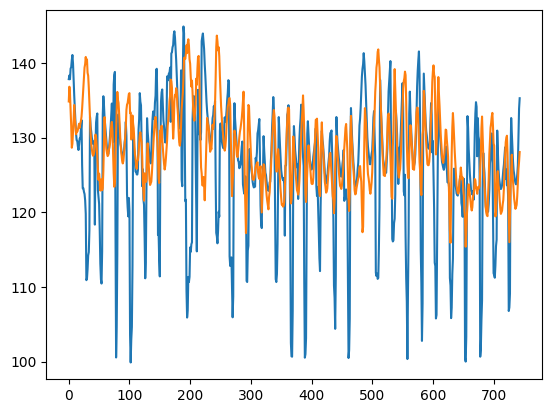

In [12]:
import matplotlib.pyplot as plt
plt.plot(y_act)
plt.plot(y_pred)
plt.show()

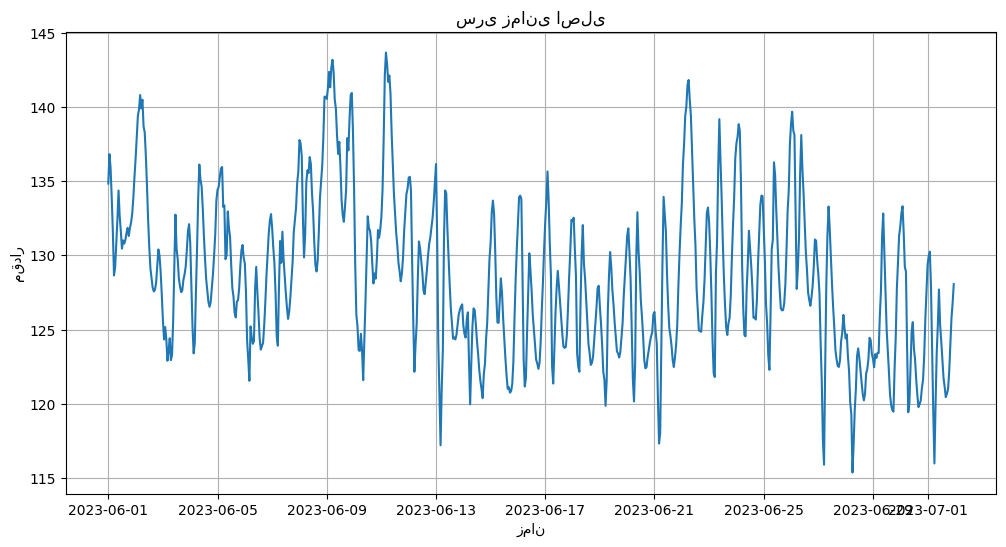

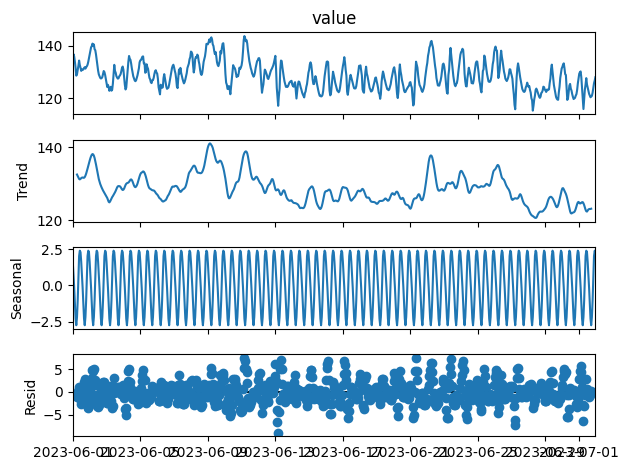

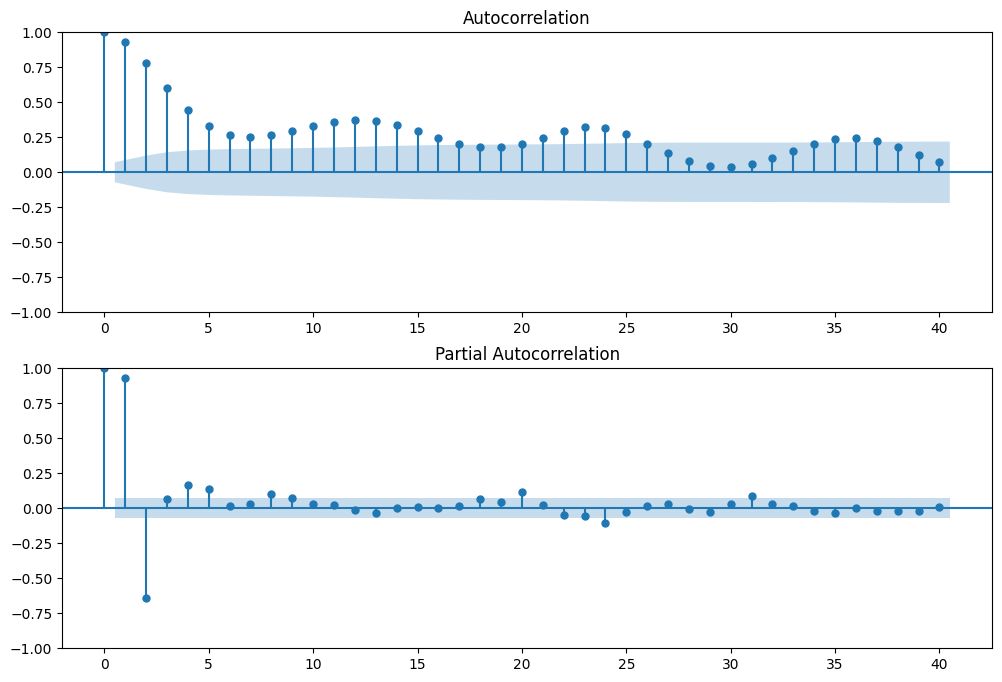

In [13]:
def plot(df):
    # نمایش داده‌ها
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df["value"])
    plt.title('سری زمانی اصلی')
    plt.xlabel('زمان')
    plt.ylabel('مقدار')
    plt.grid(True)
    plt.show()

    # تجزیه سری زمانی
    decomposition = seasonal_decompose(df["value"], model='additive', period=12)
    decomposition.plot()
    plt.show()

    # ACF و PACF برای تشخیص پارامترها
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    plot_acf(df["value"], ax=ax1, lags=40)
    plot_pacf(df["value"], ax=ax2, lags=40)
    plt.show()
plot(df_io)

MAE: 1.41
MSE: 2.13
RMSE: 1.46


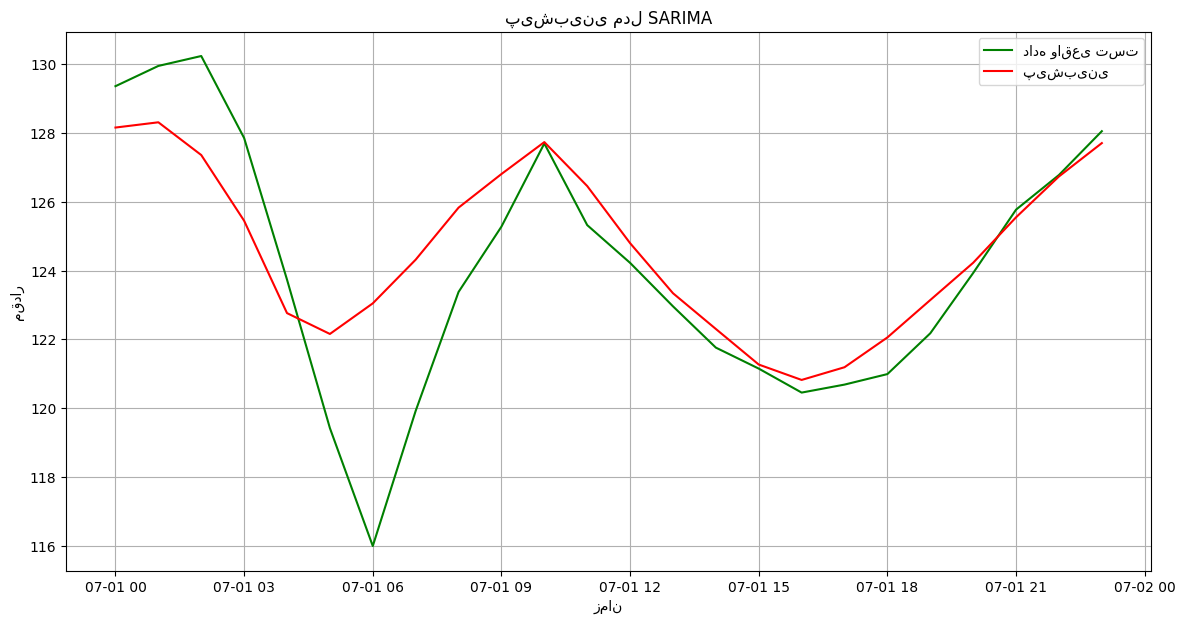

In [14]:
# پیش‌بینی
forecast_steps = len(test)
forecast = results.get_forecast(steps=forecast_steps,exog=test[cols])
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# محاسبه معیارهای ارزیابی
mae = mean_absolute_error(test['value'], forecast_mean)
mse = mean_squared_error(test['value'], forecast_mean)**0.5
rmse = np.sqrt(mse)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

# نمایش نتایج
plt.figure(figsize=(14, 7))
#plt.plot(train.index, train['value'], label='داده آموزش', color='blue')
plt.plot(test.index, test['value'], label='داده واقعی تست', color='green')
plt.plot(test.index, forecast_mean, label='پیش‌بینی', color='red')
'''
plt.fill_between(test.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 color='pink', alpha=0.3, label='فاصله اطمینان 95%')
'''
plt.title('پیش‌بینی مدل SARIMA')
plt.xlabel('زمان')
plt.ylabel('مقدار')
plt.legend()
plt.grid(True)
plt.show()

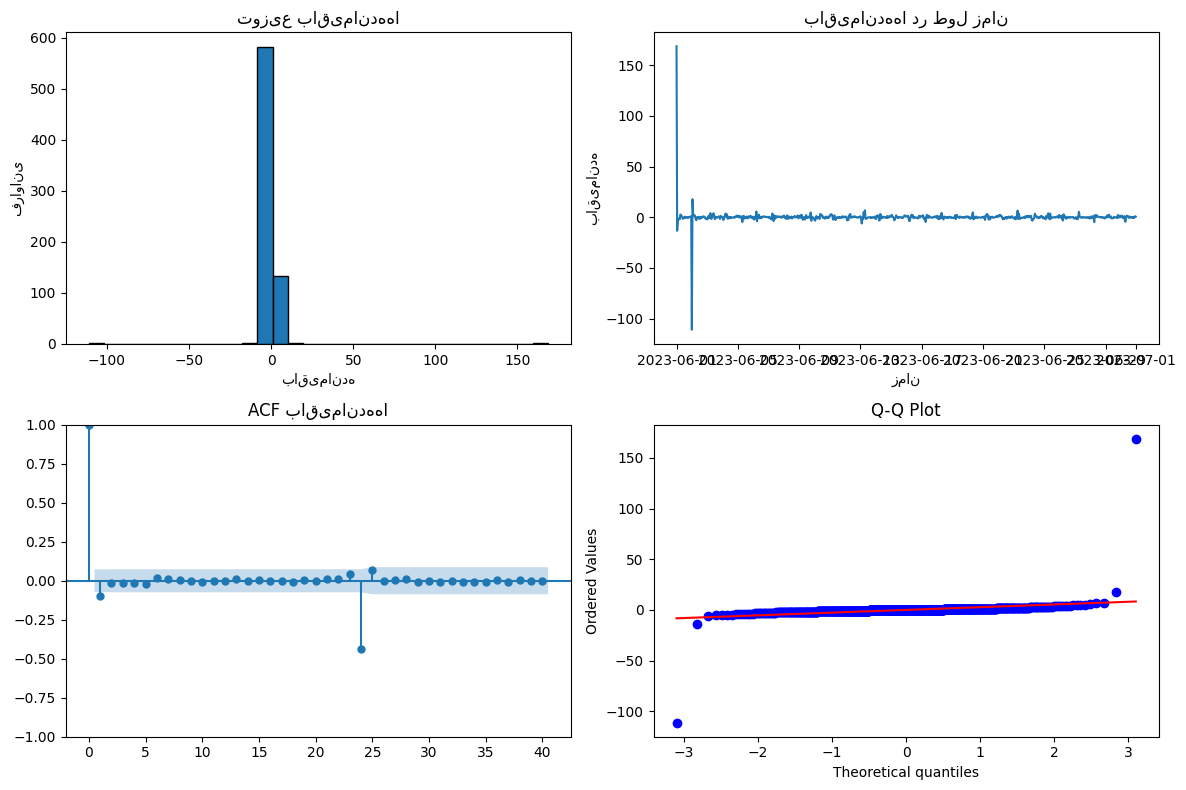

In [15]:
# تحلیل باقیمانده‌ها
residuals = results.resid

plt.figure(figsize=(12, 8))

# توزیع باقیمانده‌ها
plt.subplot(2, 2, 1)
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('توزیع باقیمانده‌ها')
plt.xlabel('باقیمانده')
plt.ylabel('فراوانی')

# باقیمانده‌ها در زمان
plt.subplot(2, 2, 2)
plt.plot(residuals)
plt.title('باقیمانده‌ها در طول زمان')
plt.xlabel('زمان')
plt.ylabel('باقیمانده')

# ACF باقیمانده‌ها
plt.subplot(2, 2, 3)
plot_acf(residuals, lags=40, ax=plt.gca())
plt.title('ACF باقیمانده‌ها')

# Q-Q Plot
plt.subplot(2, 2, 4)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')

plt.tight_layout()
plt.show()

In [32]:
time = np.datetime64("2023-07-01")
name = "پرند"
code = "G11"
base_features = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value",
                     "forecast", "status", "season", "datetime", "generation_with_24_delay"]


time3 = time
time1 = time - np.timedelta64(120,"D")
time2 = time + np.timedelta64(1,"D")

dff = df[(df["name"] == name) & (df["code"] == code)]
times = pd.to_datetime(dff["datetime"])
dfff = dff[(time1 <= times) & (times < time2)]

base_feature_selector = Feature_selector(dfff, target="generation")
base_feature_selector.select(features_to_select=base_features)
dff_o = base_feature_selector.df.copy()

y_act  = dff_o["generation"].to_numpy()
y_pred = test_model(models, dff_o, n_mimo,all_col=all_col)

logger.info("y_pred generate")
dates = pd.to_datetime(dfff["datetime"]).to_numpy()
cols = [
'temperature',
'humidity',
'dew',
'surface_pressure',
'forecast',
'generation_with_24_delay']
df_io = pd.DataFrame({col:dfff[col].to_numpy() for col in cols}, index=dates)
df_io["value"] = y_pred
df_io = df_io.asfreq('h')


mask_test = (time3 <= df_io.index)
train = df_io[~mask_test]
test = df_io[mask_test]

# تعریف پارامترهای SARIMA
# SARIMA(p, d, q)(P, D, Q, s)
p, d, q = 1, 1, 1          # پارامترهای غیر فصلی
P, D, Q, s = 1, 1, 1, 24   # پارامترهای فصلی (s=12 برای داده ماهانه)

# آموزش مدل
model = SARIMAX(train['value'],
                order=(p, d, q),
                exog=train[cols],
                seasonal_order=(P, D, Q, s),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=True, maxiter=1000, method='nm')
logger.info("Sarimax trained")

# پیش‌بینی
forecast_steps = len(test)
forecast = results.get_forecast(steps=forecast_steps,exog=test[cols])
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# محاسبه معیارهای ارزیابی
mae = mean_absolute_error(test['value'], forecast_mean)
mse = mean_squared_error(test['value'], forecast_mean)**0.5
rmse = np.sqrt(mse)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
logger.info("finished")

forecast_mean

2025-09-27 20:27:03 - train_model - INFO - Test model: Some features have been dropped successfully
2025-09-27 20:27:03 - train_model - INFO - test rmse error: 19.12%
2025-09-27 20:27:03 - train_model - INFO - test threshold error: 0.81%
2025-09-27 20:27:03 - train_model - INFO - y_pred generate
C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\optimizer.py:748: RuntimeWarning: Maximum number of iterations has been exceeded.
  retvals = optimize.fmin(f, start_params, args=fargs, xtol=xtol,
C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
2025-09-27 20:31:49 - train_model - INFO - Sarimax trained
2025-09-27 20:31:49 - train_model - INFO - finished


MAE: 1.31
MSE: 1.80
RMSE: 1.34


2023-07-01 00:00:00    129.054096
2023-07-01 01:00:00    129.028857
2023-07-01 02:00:00    128.344017
2023-07-01 03:00:00    127.021942
2023-07-01 04:00:00    124.883540
2023-07-01 05:00:00    123.801071
2023-07-01 06:00:00    124.181343
2023-07-01 07:00:00    124.671469
2023-07-01 08:00:00    126.166558
2023-07-01 09:00:00    127.734955
2023-07-01 10:00:00    127.918703
2023-07-01 11:00:00    126.683951
2023-07-01 12:00:00    125.597392
2023-07-01 13:00:00    124.248406
2023-07-01 14:00:00    123.328607
2023-07-01 15:00:00    122.314077
2023-07-01 16:00:00    121.863234
2023-07-01 17:00:00    121.844936
2023-07-01 18:00:00    122.499440
2023-07-01 19:00:00    123.638664
2023-07-01 20:00:00    124.992397
2023-07-01 21:00:00    126.564254
2023-07-01 22:00:00    127.736337
2023-07-01 23:00:00    128.581340
Freq: h, Name: predicted_mean, dtype: float64

In [ ]:
is_test_data = dfff[mask_test]["is_good_peak"] == 3

In [43]:
times.iloc[0]

Timestamp('2021-03-24 12:00:00')

In [ ]:
def get_err(y_pred,y_act,is_test_data):
    if is_test_data.any():
        err = (y_pred - y_act)
        peak_err = err[is_test_data.to_numpy()]
        t = np.count_nonzero(is_test_data)
        return (peak_err.to_numpy()**2).mean(),t
    else:
        return 0,0

SyntaxError: '(' was never closed (747724147.py, line 6)

In [ ]:
def predict_sarimax(df,model,time,name,code,base_features,window,first_time):
    

    time3 = time
    time1 = time - np.timedelta64(window,"D")
    time2 = time + np.timedelta64(1,"D")
    time1 = max(time1,first_time)
    
    dff = df[(df["name"] == name) & (df["code"] == code)]
    times = pd.to_datetime(dff["datetime"])
    dfff = dff[(time1 <= times) & (times < time2)]

    base_feature_selector = Feature_selector(dfff, target="generation")
    base_feature_selector.select(features_to_select=base_features)
    dff_o = base_feature_selector.df.copy()

    y_act  = dff_o["generation"].to_numpy()
    y_pred = test_model(model, dff_o, n_mimo,all_col=all_col)

    logger.info("y_pred generate")
    dates = pd.to_datetime(dfff["datetime"]).to_numpy()
    cols = [
    'temperature',
    'humidity',
    'dew',
    'surface_pressure',
    'forecast',
    'generation_with_24_delay']
    df_io = pd.DataFrame({col:dfff[col].to_numpy() for col in cols}, index=dates)
    df_io["value"] = y_pred
    df_io = df_io.asfreq('h')


    mask_test = (time3 <= df_io.index)
    train = df_io[~mask_test]
    test = df_io[mask_test]

    # تعریف پارامترهای SARIMA
    # SARIMA(p, d, q)(P, D, Q, s)
    p, d, q = 1, 1, 1          # پارامترهای غیر فصلی
    P, D, Q, s = 1, 1, 1, 24   # پارامترهای فصلی (s=12 برای داده ماهانه)

    # آموزش مدل
    model = SARIMAX(train['value'],
                    order=(p, d, q),
                    exog=train[cols],
                    seasonal_order=(P, D, Q, s),
                    enforce_stationarity=False,
                    enforce_invertibility=False)

    results = model.fit(disp=True, maxiter=1000, method='nm')
    logger.info("Sarimax trained")

    # پیش‌بینی
    forecast_steps = len(test)
    forecast = results.get_forecast(steps=forecast_steps,exog=test[cols])
    forecast_mean = forecast.predicted_mean
    forecast_ci = forecast.conf_int()

    # محاسبه معیارهای ارزیابی
    mae = mean_absolute_error(test['value'], forecast_mean)
    mse = mean_squared_error(test['value'], forecast_mean)**0.5
    rmse = np.sqrt(mse)

    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    logger.info("finished")

    return forecast_mean,test['value'],dfff[mask_test]["is_good_peak"]

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

first_time = np.datetime64("2021-03-24 12:00:00")
window_time = 15

time = np.datetime64("2023-07-01")
name = "پرند"
code = "G11"
base_features = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value",
                    "forecast", "status", "season", "datetime", "generation_with_24_delay"]
model = models

2025-09-27 20:59:42 - train_model - INFO - Test model: Some features have been dropped successfully
2025-09-27 20:59:42 - train_model - INFO - test rmse error: 7.43%
2025-09-27 20:59:42 - train_model - INFO - test threshold error: 0.83%
2025-09-27 20:59:42 - train_model - INFO - y_pred generate
C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\optimizer.py:748: RuntimeWarning: Maximum number of iterations has been exceeded.
  retvals = optimize.fmin(f, start_params, args=fargs, xtol=xtol,
C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
2025-09-27 21:00:02 - train_model - INFO - Sarimax trained
2025-09-27 21:00:02 - train_model - INFO - finished


MAE: 1.78
MSE: 2.41
RMSE: 1.55


In [ ]:
start_date = pd.Timestamp('2024-06-01')
end_date = pd.Timestamp('2024-07-01')
date_range = pd.date_range(start=start_date, end=end_date, freq='D')
b = []
for time in date_range:
    y_pred,y_act,label = predict_sarimax(df,model,time,name,code,base_features,window_time,first_time)
    print(time,get_err(y_pred,y_act,label>=3))
    b.append((time,get_err(y_pred,y_act,label>=3)[0]))

2025-09-27 21:05:34 - train_model - INFO - Test model: Some features have been dropped successfully
2025-09-27 21:05:34 - train_model - INFO - test rmse error: 6.99%
2025-09-27 21:05:34 - train_model - INFO - test threshold error: 0.66%
2025-09-27 21:05:34 - train_model - INFO - y_pred generate
C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\optimizer.py:748: RuntimeWarning: Maximum number of iterations has been exceeded.
  retvals = optimize.fmin(f, start_params, args=fargs, xtol=xtol,
C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
2025-09-27 21:05:55 - train_model - INFO - Sarimax trained
2025-09-27 21:05:55 - train_model - INFO - finished
2025-09-27 21:05:55 - train_model - INFO - Test model: Some features have been dropped successfully
2025-09-27 21:05:5

MAE: 1.97
MSE: 2.17
RMSE: 1.47
2024-06-01 00:00:00 (75.03304294641036, 15)


C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\optimizer.py:748: RuntimeWarning: Maximum number of iterations has been exceeded.
  retvals = optimize.fmin(f, start_params, args=fargs, xtol=xtol,
C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
2025-09-27 21:06:15 - train_model - INFO - Sarimax trained
2025-09-27 21:06:15 - train_model - INFO - finished
2025-09-27 21:06:15 - train_model - INFO - Test model: Some features have been dropped successfully
2025-09-27 21:06:15 - train_model - INFO - test rmse error: 7.10%
2025-09-27 21:06:15 - train_model - INFO - test threshold error: 0.68%
2025-09-27 21:06:15 - train_model - INFO - y_pred generate


MAE: 1.89
MSE: 2.43
RMSE: 1.56
2024-06-02 00:00:00 (15.571473411150457, 3)


C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\optimizer.py:748: RuntimeWarning: Maximum number of iterations has been exceeded.
  retvals = optimize.fmin(f, start_params, args=fargs, xtol=xtol,
C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
2025-09-27 21:06:35 - train_model - INFO - Sarimax trained
2025-09-27 21:06:35 - train_model - INFO - finished
2025-09-27 21:06:35 - train_model - INFO - Test model: Some features have been dropped successfully
2025-09-27 21:06:35 - train_model - INFO - test rmse error: 7.03%
2025-09-27 21:06:35 - train_model - INFO - test threshold error: 0.67%
2025-09-27 21:06:35 - train_model - INFO - y_pred generate


...

C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\optimizer.py:748: RuntimeWarning: Maximum number of iterations has been exceeded.
  retvals = optimize.fmin(f, start_params, args=fargs, xtol=xtol,
C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
2025-09-27 21:13:13 - train_model - INFO - Sarimax trained
2025-09-27 21:13:13 - train_model - INFO - finished
2025-09-27 21:13:13 - train_model - INFO - Test model: Some features have been dropped successfully
2025-09-27 21:13:13 - train_model - INFO - test rmse error: 6.83%
2025-09-27 21:13:13 - train_model - INFO - test threshold error: 0.71%
2025-09-27 21:13:13 - train_model - INFO - y_pred generate


MAE: 3.17
MSE: 4.83
RMSE: 2.20
2024-06-21 00:00:00 (174.19249618038899, 18)


C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\optimizer.py:748: RuntimeWarning: Maximum number of iterations has been exceeded.
  retvals = optimize.fmin(f, start_params, args=fargs, xtol=xtol,
C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
2025-09-27 21:13:31 - train_model - INFO - Sarimax trained
2025-09-27 21:13:31 - train_model - INFO - finished
2025-09-27 21:13:31 - train_model - INFO - Test model: Some features have been dropped successfully


MAE: 1.66
MSE: 2.15
RMSE: 1.47
2024-06-22 00:00:00 (1.4134072350590088, 2)


2025-09-27 21:13:31 - train_model - INFO - test rmse error: 6.82%
2025-09-27 21:13:31 - train_model - INFO - test threshold error: 0.72%
2025-09-27 21:13:31 - train_model - INFO - y_pred generate
C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\optimizer.py:748: RuntimeWarning: Maximum number of iterations has been exceeded.
  retvals = optimize.fmin(f, start_params, args=fargs, xtol=xtol,
C:\Users\alireza\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# پیش‌بینی روی داده آموزشی
train_predictions = results.get_prediction(start=train.index[0], end=train.index[-1])
train_predicted = train_predictions.predicted_mean

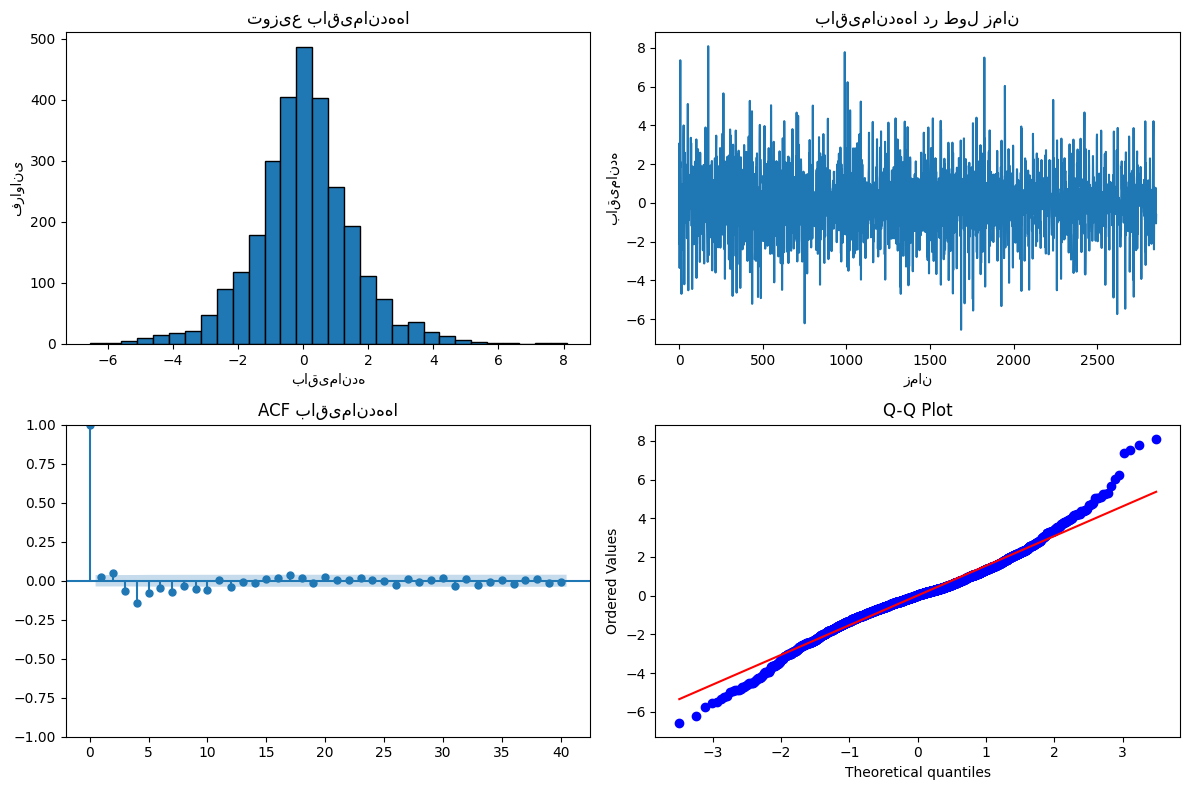

In [18]:
# تحلیل باقیمانده‌ها
residuals =(train_predicted.to_numpy()[26:]-y_pred[26:-24])
#residuals = results.resid

plt.figure(figsize=(12, 8))

# توزیع باقیمانده‌ها
plt.subplot(2, 2, 1)
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('توزیع باقیمانده‌ها')
plt.xlabel('باقیمانده')
plt.ylabel('فراوانی')

# باقیمانده‌ها در زمان
plt.subplot(2, 2, 2)
plt.plot(residuals)
plt.title('باقیمانده‌ها در طول زمان')
plt.xlabel('زمان')
plt.ylabel('باقیمانده')

# ACF باقیمانده‌ها
plt.subplot(2, 2, 3)
plot_acf(residuals, lags=40, ax=plt.gca())
plt.title('ACF باقیمانده‌ها')

# Q-Q Plot
plt.subplot(2, 2, 4)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')

plt.tight_layout()
plt.show()